# Metodología CRISP-DM — Rentas Cedidas

**Cross-Industry Standard Process for Data Mining** aplicado al Sistema de Análisis y Pronóstico de Rentas Cedidas para Departamentos y Distritos de Colombia.

---

```
         ┌──────────────────────┐
         │ 1. Comprensión del   │
         │    Negocio           │
         └──────────┬───────────┘
                    │
         ┌──────────▼───────────┐
         │ 2. Comprensión de    │
         │    los Datos         │
         └──────────┬───────────┘
                    │
         ┌──────────▼───────────┐
         │ 3. Preparación de    │
         │    los Datos         │
         └──────────┬───────────┘
                    │
         ┌──────────▼───────────┐
         │ 4. Modelado          │
         └──────────┬───────────┘
                    │
         ┌──────────▼───────────┐
         │ 5. Evaluación        │
         └──────────┬───────────┘
                    │
         ┌──────────▼───────────┐
         │ 6. Despliegue        │
         └──────────────────────┘
```

| Fase | Notebook(s) asociado(s) | Artefactos |
|------|------------------------|------------|
| 1. Comprensión del Negocio | `docs/contexto_rentas_cedidas.md` | Objetivos, criterios de éxito |
| 2. Comprensión de los Datos | `01_EDA_Completo.ipynb` | Perfiles estadísticos, calidad |
| 3. Preparación de los Datos | `02_Estacionalidad.ipynb`, `03_Correlacion_Macro.ipynb` | `serie_mensual.csv`, `serie_mensual_macro.csv` |
| 4. Modelado | `04_SARIMAX`, `05_Prophet`, `06_XGBoost`, `07_LSTM` | Forecasts por modelo |
| 5. Evaluación | `08_Comparacion_Modelos.ipynb` | Métricas comparadas, ranking |
| 6. Despliegue | `09_Benchmarking_Territorial.ipynb` | Sistema STAR, dashboards |

In [ ]:
# ── Configuración global ──────────────────────────────────────
import sys, os
from pathlib import Path

# Resolver rutas desde legacy/
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'legacy' else NOTEBOOK_DIR
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'

# Cargar config centralizada
os.chdir(NOTEBOOKS_DIR)
sys.path.insert(0, str(NOTEBOOKS_DIR))
%run 00_config.py
os.chdir(NOTEBOOK_DIR)

Guardado en: c:\Users\efren\Music\ESTRUCTURA DATOS RENTAS V2\outputs\figures\crisp_dm_ciclo_completo.png


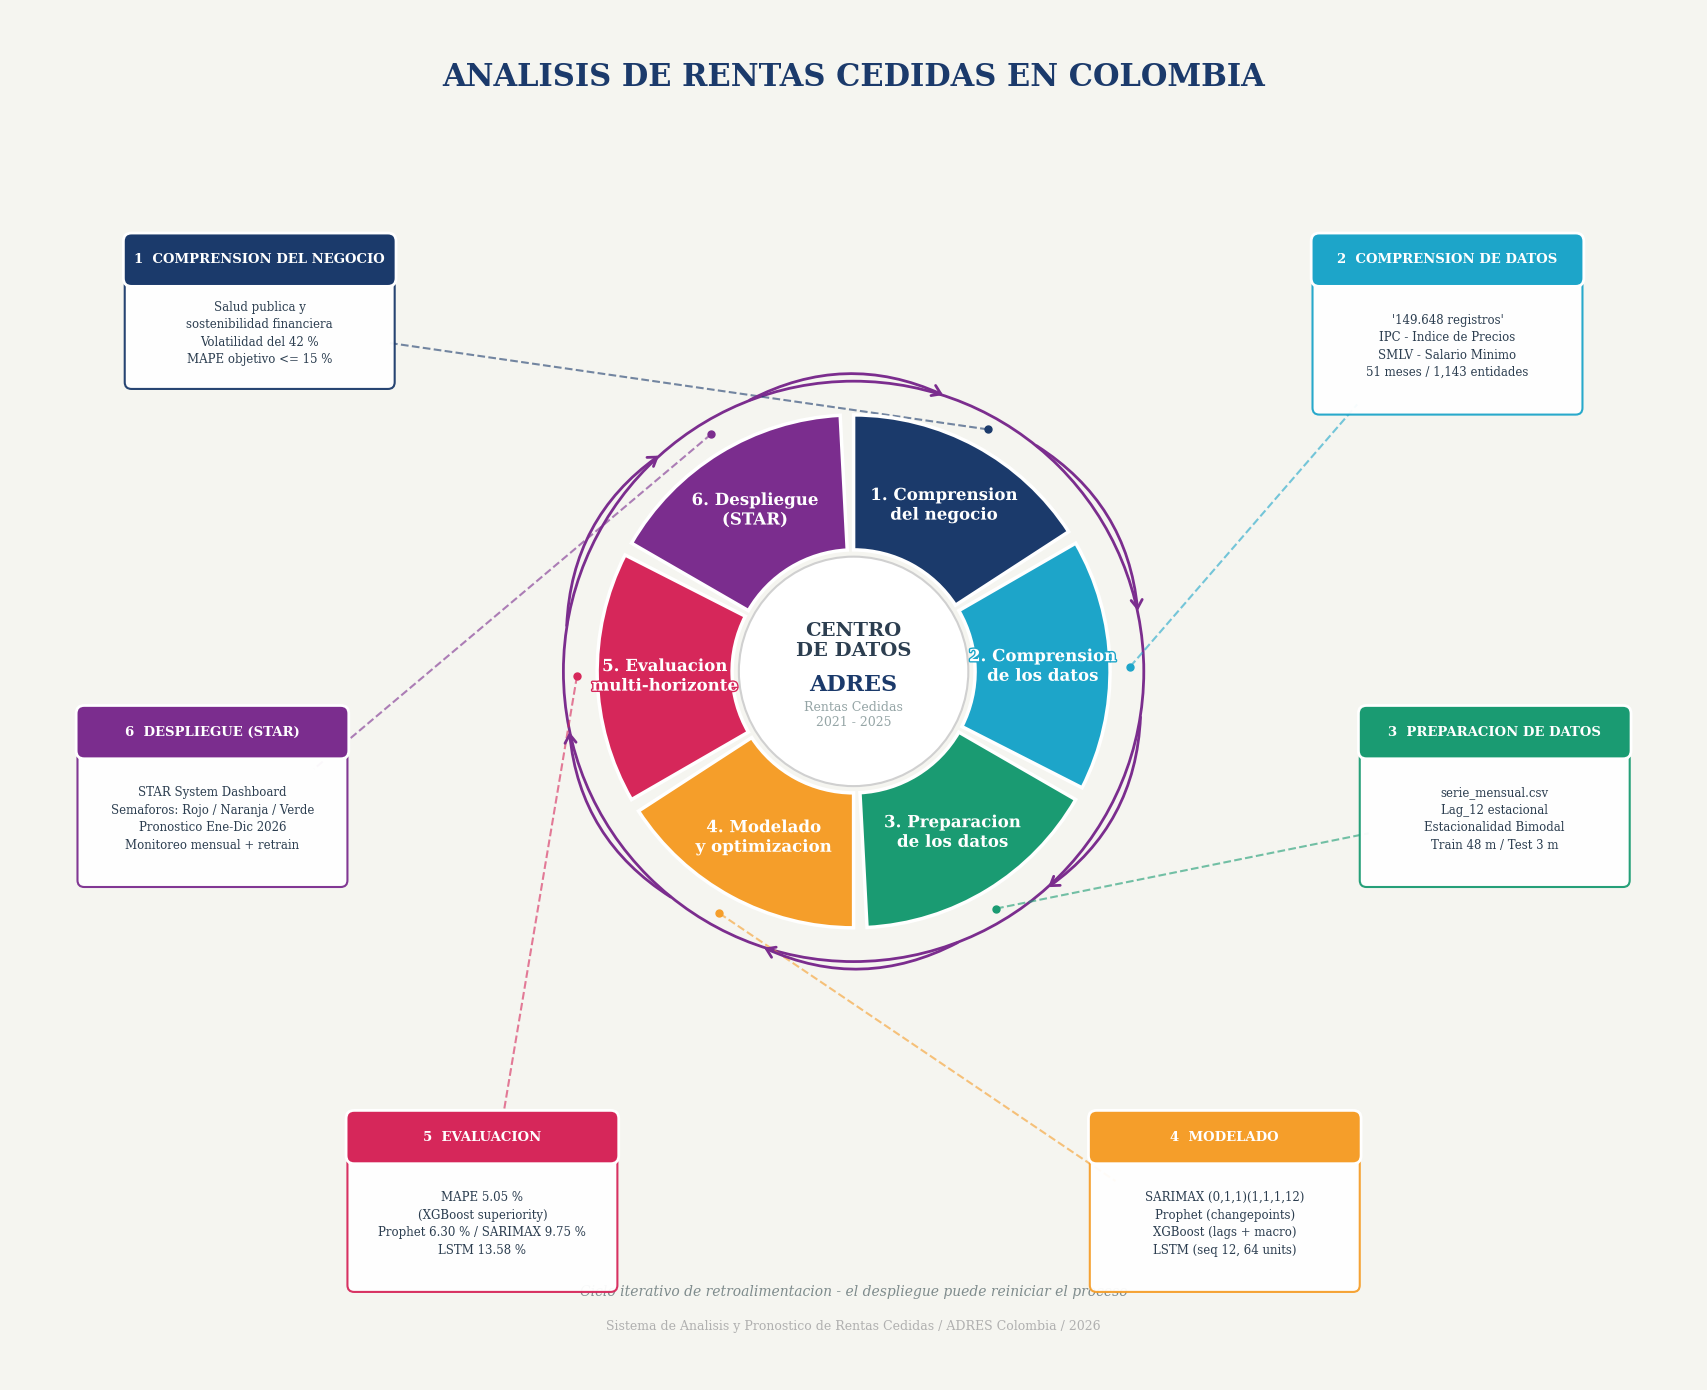

In [4]:
# ── CRISP-DM Combinado: Rueda + Infografia de detalle ────────
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, FancyArrowPatch, FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'legacy' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Paleta ────────────────────────────────────────────────────
BG = '#F5F5F0'
C_CENTER_BG = '#FFFFFF'
C_CENTER_TXT = '#2C3E50'
C_ARROW_RING = '#7B2D8E'
C_FOOT = '#7F8C8D'
C_DETAIL_TXT = '#2C3E50'
C_TITLE = '#1B3A6B'

# ── Fases con datos del sistema ──────────────────────────────
PHASES = [
    {'name': '1. Comprension\ndel negocio',    'color': '#1B3A6B'},
    {'name': '2. Comprension\nde los datos',   'color': '#1DA5C9'},
    {'name': '3. Preparacion\nde los datos',   'color': '#1A9B72'},
    {'name': '4. Modelado\ny optimizacion',    'color': '#F59E2A'},
    {'name': '5. Evaluacion\nmulti-horizonte', 'color': '#D6275A'},
    {'name': '6. Despliegue\n(STAR)',           'color': '#7B2D8E'},
]

# Callouts: posicion (x,y), titulo, lineas de detalle, anclaje en la rueda (angulo)
CALLOUTS = [
    {'title': '1  COMPRENSION DEL NEGOCIO',
     'lines': ['Salud publica y\nsostenibilidad financiera',
               'Volatilidad del 42 %',
               'MAPE objetivo <= 15 %'],
     'pos': (-8.8, 5.5), 'anchor_deg': 61},
    {'title': '2  COMPRENSION DE DATOS',
     'lines': ["'149.648 registros'",
               'IPC - Indice de Precios',
               'SMLV - Salario Minimo',
               '51 meses / 1,143 entidades'],
     'pos': (8.8, 5.5), 'anchor_deg': 1},
    {'title': '3  PREPARACION DE DATOS',
     'lines': ['serie_mensual.csv',
               'Lag_12 estacional',
               'Estacionalidad Bimodal',
               'Train 48 m / Test 3 m'],
     'pos': (9.5, -1.5), 'anchor_deg': -59},
    {'title': '4  MODELADO',
     'lines': ['SARIMAX (0,1,1)(1,1,1,12)',
               'Prophet (changepoints)',
               'XGBoost (lags + macro)',
               'LSTM (seq 12, 64 units)'],
     'pos': (5.5, -7.5), 'anchor_deg': -119},
    {'title': '5  EVALUACION',
     'lines': ['MAPE 5.05 %',
               '(XGBoost superiority)',
               'Prophet 6.30 % / SARIMAX 9.75 %',
               'LSTM 13.58 %'],
     'pos': (-5.5, -7.5), 'anchor_deg': -179},
    {'title': '6  DESPLIEGUE (STAR)',
     'lines': ['STAR System Dashboard',
               'Semaforos: Rojo / Naranja / Verde',
               'Pronostico Ene-Dic 2026',
               'Monitoreo mensual + retrain'],
     'pos': (-9.5, -1.5), 'anchor_deg': 121},
]

n = len(PHASES)
GAP_DEG  = 3.0
SPAN_DEG = (360 - n * GAP_DEG) / n
R_INNER, R_OUTER, R_RING = 1.80, 3.80, 4.30

start_angles = []
a = 90
for i in range(n):
    start_angles.append(a)
    a -= (SPAN_DEG + GAP_DEG)

# ── Figura panoramica ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 14), subplot_kw={'aspect': 'equal'})
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.axis('off')

# ── Titulo principal ─────────────────────────────────────────
ax.text(0, 8.8,
        'ANALISIS DE RENTAS CEDIDAS EN COLOMBIA',
        fontsize=22, fontweight='bold', fontfamily='serif',
        color=C_TITLE, ha='center', va='center', zorder=20)

# ── 1. Donut wheel ───────────────────────────────────────────
for i, phase in enumerate(PHASES):
    theta1 = start_angles[i] - SPAN_DEG
    theta2 = start_angles[i]
    wedge = Wedge((0, 0), R_OUTER, theta1, theta2, width=R_OUTER - R_INNER,
                  facecolor=phase['color'], edgecolor='white', linewidth=2.5, zorder=5)
    ax.add_patch(wedge)
    mid_a = np.radians((theta1 + theta2) / 2)
    r_t = (R_INNER + R_OUTER) / 2
    ax.text(r_t * np.cos(mid_a), r_t * np.sin(mid_a), phase['name'],
            fontsize=12, fontweight='bold', color='white', ha='center', va='center',
            fontfamily='serif', linespacing=1.2, zorder=7,
            path_effects=[pe.withStroke(linewidth=2, foreground=phase['color'])])

# Centro blanco
ax.add_patch(plt.Circle((0, 0), R_INNER - 0.10, facecolor=C_CENTER_BG,
                         edgecolor='#D0D0D0', linewidth=1.5, zorder=6))
ax.text(0, 0.45, 'CENTRO\nDE DATOS', fontsize=14, fontweight='bold',
        color=C_CENTER_TXT, ha='center', va='center', fontfamily='serif',
        linespacing=1.1, zorder=10)
ax.text(0, -0.20, 'ADRES', fontsize=16, fontweight='bold',
        color=C_TITLE, ha='center', va='center', fontfamily='serif', zorder=10)
ax.text(0, -0.65, 'Rentas Cedidas\n2021 - 2025', fontsize=9,
        color='#95A5A6', ha='center', va='center', fontfamily='serif',
        linespacing=1.2, zorder=10)

# ── 2. Anillo exterior con flechas ───────────────────────────
ax.add_patch(plt.Circle((0, 0), R_RING, fill=False,
                         edgecolor=C_ARROW_RING, linewidth=2.0, zorder=3))
arrow_pos = [start_angles[i] - SPAN_DEG / 2 for i in range(n)]
for i in range(n):
    a_s = np.radians(arrow_pos[i] - 10)
    a_e = np.radians(arrow_pos[(i + 1) % n] + 10)
    ax.add_patch(FancyArrowPatch(
        (R_RING * np.cos(a_s), R_RING * np.sin(a_s)),
        (R_RING * np.cos(a_e), R_RING * np.sin(a_e)),
        arrowstyle='->,head_length=6,head_width=4',
        color=C_ARROW_RING, linewidth=2.0,
        connectionstyle='arc3,rad=-0.25', zorder=4))

# ── 3. Callout boxes con detalle por fase ────────────────────
for i, (co, phase) in enumerate(zip(CALLOUTS, PHASES)):
    cx, cy = co['pos']
    color = phase['color']

    # Caja del titulo
    bw, bh_title = 3.80, 0.55
    title_box = FancyBboxPatch((cx - bw/2, cy - bh_title/2 + 0.60), bw, bh_title,
                               boxstyle='round,pad=0.12',
                               facecolor=color, edgecolor='white',
                               linewidth=2, zorder=12)
    ax.add_patch(title_box)
    ax.text(cx, cy + 0.60, co['title'],
            fontsize=9.5, fontweight='bold', color='white',
            ha='center', va='center', fontfamily='serif', zorder=13)

    # Caja del detalle
    detail_text = '\n'.join(co['lines'])
    n_lines = len(co['lines'])
    bh_det = 0.38 * n_lines + 0.30
    det_y = cy + 0.60 - bh_title/2 - bh_det/2 - 0.10
    detail_box = FancyBboxPatch((cx - bw/2, det_y - bh_det/2), bw, bh_det,
                                boxstyle='round,pad=0.10',
                                facecolor='white', edgecolor=color,
                                linewidth=1.5, alpha=0.95, zorder=11)
    ax.add_patch(detail_box)
    ax.text(cx, det_y, detail_text,
            fontsize=8.5, color=C_DETAIL_TXT, ha='center', va='center',
            fontfamily='serif', linespacing=1.45, zorder=12)

    # Linea conectora: del borde de la rueda al callout
    anchor_rad = np.radians(co['anchor_deg'])
    wx = (R_OUTER + 0.30) * np.cos(anchor_rad)
    wy = (R_OUTER + 0.30) * np.sin(anchor_rad)

    # Punto mas cercano del callout
    box_cx = cx
    box_cy = det_y
    dx = box_cx - wx
    dy = box_cy - wy
    dist = np.sqrt(dx**2 + dy**2)
    # punto en el borde de la caja
    bx = box_cx - dx/dist * min(bw/2, abs(dx))
    by = box_cy - dy/dist * min(bh_det/2 + 0.30, abs(dy))

    ax.plot([wx, bx], [wy, by], color=color, lw=1.5,
            alpha=0.6, ls='--', zorder=3)
    ax.plot(wx, wy, 'o', color=color, markersize=5, zorder=4)

# ── 4. Pie de pagina ─────────────────────────────────────────
ax.text(0, -9.2,
        'Ciclo iterativo de retroalimentacion - el despliegue puede reiniciar el proceso',
        fontsize=10, color=C_FOOT, ha='center', va='center',
        fontfamily='serif', style='italic', zorder=10)
ax.text(0, -9.7,
        'Sistema de Analisis y Pronostico de Rentas Cedidas / ADRES Colombia / 2026',
        fontsize=9, color='#B0B0B0', ha='center', va='center',
        fontfamily='serif', zorder=10)

# ── Limites y guardado ───────────────────────────────────────
ax.set_xlim(-12.5, 12.5)
ax.set_ylim(-10.5, 9.8)
plt.tight_layout()
out = OUT_DIR / 'crisp_dm_ciclo_completo.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=BG)
print(f"Guardado en: {out}")
plt.show()

---
## Fase 1 — Comprensión del Negocio (*Business Understanding*)

### 1.1 Contexto institucional

Las **Rentas Cedidas** son impuestos etiquetados para la salud (licores, cigarrillos, juegos de azar) que financian aproximadamente el **15 % del Régimen Subsidiado**, beneficiando a **24 millones** de personas. La administración recae en la **ADRES** (Administradora de los Recursos del Sistema de Salud).

### 1.2 Problema de negocio

| Dimensión | Descripción |
|-----------|-------------|
| **Volatilidad** | Desviación estándar del 42 % (vs. 18 % de otras fuentes) |
| **Variabilidad anual** | Cambios de hasta el 40 % entre años |
| **Asimetría territorial** | 5 departamentos concentran el 68 % del recaudo |
| **Método actual** | Proyección lineal simple con errores > 25 % |

### 1.3 Objetivos del proyecto

1. **Pronosticar** el recaudo mensual de Rentas Cedidas con un error ≤ 15 % (MAPE).
2. **Identificar** los factores macroeconómicos que más afectan la dinámica del recaudo.
3. **Clasificar** territorialmente los municipios según patrones de recaudo.
4. **Diseñar** un sistema de alertas tempranas (STAR) para la gestión proactiva.

### 1.4 Criterios de éxito

| Criterio | Umbral de éxito |
|----------|----------------|
| MAPE mensual | ≤ 15 % |
| Dirección correcta del pronóstico | ≥ 2 de 3 meses test |
| Sesgo absoluto acumulado | ≤ $50 MM trimestral |
| Cobertura del intervalo de confianza 95 % | ≥ 80 % |

In [ ]:
# ── 1.5  Inventario de recursos del proyecto ─────────────────
print("="*70)
print("INVENTARIO DE RECURSOS — CRISP-DM Fase 1")
print("="*70)

# Fuente principal
print(f"\n📂 Fuente principal : {DATA_FILE.name}")
print(f"   Existe           : {DATA_FILE.exists()}")

# Datasets procesados
processed = list(DATA_PROCESSED.glob('*.csv'))
print(f"\n📁 Datasets procesados ({len(processed)}):")
for p in sorted(processed):
    size_kb = p.stat().st_size / 1024
    print(f"   · {p.name:40s} {size_kb:8.1f} KB")

# Pronósticos generados
forecasts = list(OUTPUTS_FORECASTS.glob('*.csv'))
print(f"\n📊 Pronósticos generados ({len(forecasts)}):")
for f in sorted(forecasts):
    print(f"   · {f.name}")

# Notebooks pipeline
nbs = sorted(NOTEBOOKS_DIR.glob('*.ipynb'))
print(f"\n📓 Pipeline de notebooks ({len(nbs)}):")
for nb in nbs:
    print(f"   · {nb.name}")

---
## Fase 2 — Comprensión de los Datos (*Data Understanding*)

### 2.1 Recolección inicial

| Atributo | Valor |
|----------|-------|
| Fuente | ADRES — `BaseRentasCedidasVF.xlsx` |
| Registros | 149,648 |
| Columnas | ~20 (fecha, valor, entidad, departamento, SubGrupo, etc.) |
| Periodo | Octubre 2021 – Diciembre 2025 (51 meses) |
| Entidades únicas | 1,143 |
| SubGrupos | 10 categorías de renta |
| Granularidad | Mensual por entidad × SubGrupo |

In [ ]:
# ── 2.2  Carga y perfil del dataset crudo ────────────────────
df_raw = cargar_datos(filtrar_anos=True, verbose=True)

print("\n── Tipos de datos ──")
print(df_raw.dtypes.to_string())

print("\n── Valores nulos ──")
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.any() else "Sin nulos")

print("\n── Estadísticas descriptivas (ValorRecaudo) ──")
print(df_raw[COL_VALOR].describe().apply(lambda x: f'{x:,.2f}'))

In [ ]:
# ── 2.3  Exploración de dimensiones clave ────────────────────
print("── Cobertura temporal ──")
print(f"Fecha mínima : {df_raw[COL_FECHA].min().strftime('%Y-%m-%d')}")
print(f"Fecha máxima : {df_raw[COL_FECHA].max().strftime('%Y-%m-%d')}")
print(f"Meses únicos : {df_raw[COL_FECHA].dt.to_period('M').nunique()}")

print("\n── Distribución por SubGrupo ──")
sub = df_raw.groupby('SubGrupo')[COL_VALOR].agg(['count', 'sum'])
sub.columns = ['Registros', 'Recaudo_Total']
sub['%_Recaudo'] = (sub['Recaudo_Total'] / sub['Recaudo_Total'].sum() * 100).round(2)
sub = sub.sort_values('Recaudo_Total', ascending=False)
print(sub.to_string())

print("\n── Top 10 entidades por recaudo ──")
if 'NombreEntidad' in df_raw.columns:
    col_ent = 'NombreEntidad'
elif 'Entidad' in df_raw.columns:
    col_ent = 'Entidad'
else:
    col_ent = df_raw.columns[df_raw.dtypes == 'object'][0]
top10 = df_raw.groupby(col_ent)[COL_VALOR].sum().nlargest(10)
print(top10.apply(lambda x: f'${x/1e6:,.0f}M').to_string())

In [ ]:
# ── 2.4  Verificación de calidad de datos ────────────────────
print("="*70)
print("REPORTE DE CALIDAD DE DATOS")
print("="*70)

# Completitud
completitud = (1 - df_raw.isnull().sum() / len(df_raw)) * 100
print("\n── Completitud por columna (%) ──")
print(completitud.round(2).to_string())

# Duplicados
n_dup = df_raw.duplicated().sum()
print(f"\n── Registros duplicados: {n_dup:,} ({n_dup/len(df_raw)*100:.2f}%)")

# Valores negativos en recaudo
n_neg = (df_raw[COL_VALOR] < 0).sum()
print(f"── Valores negativos en {COL_VALOR}: {n_neg:,}")

# Valores cero
n_zero = (df_raw[COL_VALOR] == 0).sum()
print(f"── Valores cero en {COL_VALOR}: {n_zero:,} ({n_zero/len(df_raw)*100:.2f}%)")

# Outliers (IQR)
Q1 = df_raw[COL_VALOR].quantile(0.25)
Q3 = df_raw[COL_VALOR].quantile(0.75)
IQR = Q3 - Q1
n_outliers = ((df_raw[COL_VALOR] < Q1 - 1.5*IQR) | (df_raw[COL_VALOR] > Q3 + 1.5*IQR)).sum()
print(f"── Outliers (IQR 1.5x): {n_outliers:,} ({n_outliers/len(df_raw)*100:.2f}%)")

print("\n✅ Calidad aceptable — datos aptos para preparación")

---
## Fase 3 — Preparación de los Datos (*Data Preparation*)

### 3.1 Estrategia de preparación

```
BaseRentasCedidasVF.xlsx  (149,648 filas × entidad × SubGrupo)
        │
        ├─[Agregación mensual]──▶ serie_mensual.csv  (51 obs)
        │                             Columnas: Periodo, ValorRecaudo
        │
        ├─[+ Variables macro]──▶ serie_mensual_macro.csv
        │                             + IPC, Salario_Minimo, UPC,
        │                               Consumo_Hogares, Desempleo
        │
        ├─[Feature Eng. LSTM]──▶ base_lstm_optimizada.csv
        │                             + lags, rolling, ratios
        │
        └─[Train / Test split]
              Train: Oct 2021 → Sep 2025  (48 meses)
              Test:  Oct 2025 → Dic 2025  (3 meses)
```

In [ ]:
# ── 3.2  Construcción de serie_mensual.csv ───────────────────
serie_path = DATA_PROCESSED / 'serie_mensual.csv'

if serie_path.exists():
    serie = pd.read_csv(serie_path, parse_dates=['Periodo'])
    print(f"✅ Serie mensual cargada: {serie_path.name}")
else:
    # Construir desde el dataset crudo
    serie = (
        df_raw
        .set_index(COL_FECHA)
        .resample('MS')[COL_VALOR]
        .sum()
        .reset_index()
        .rename(columns={COL_FECHA: 'Periodo', COL_VALOR: 'ValorRecaudo'})
    )
    serie.to_csv(serie_path, index=False)
    print(f"✅ Serie mensual creada: {serie_path.name}")

print(f"   Observaciones: {len(serie)}")
print(f"   Periodo: {serie['Periodo'].min()} → {serie['Periodo'].max()}")
print(f"   Recaudo medio mensual: ${serie['ValorRecaudo'].mean()/1e6:,.0f}M")
serie.head()

In [ ]:
# ── 3.3  Integración de variables macroeconómicas ────────────
macro_path = DATA_PROCESSED / 'serie_mensual_macro.csv'

if macro_path.exists():
    serie_macro = pd.read_csv(macro_path, parse_dates=['Periodo'])
    print(f"✅ Serie con macro cargada: {macro_path.name}")
else:
    serie_macro = serie.copy()
    serie_macro['Anio'] = serie_macro['Periodo'].dt.year
    for var in ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares', 'Desempleo']:
        serie_macro[var] = serie_macro['Anio'].map(
            {yr: vals[var] for yr, vals in MACRO_DATA.items()}
        )
    serie_macro.drop(columns='Anio', inplace=True)
    serie_macro.to_csv(macro_path, index=False)
    print(f"✅ Serie con macro creada: {macro_path.name}")

print(f"   Columnas: {list(serie_macro.columns)}")
print("\n── Variables macroeconómicas por año ──")
macro_df = pd.DataFrame(MACRO_DATA).T
macro_df.index.name = 'Año'
print(macro_df.to_string())

In [ ]:
# ── 3.4  Split Train / Test ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

serie_plot = serie.copy()
serie_plot['Periodo'] = pd.to_datetime(serie_plot['Periodo'])

train = serie_plot[serie_plot['Periodo'] <= TRAIN_END]
test  = serie_plot[serie_plot['Periodo'] >= TEST_START]

print(f"Train: {len(train)} meses  ({train['Periodo'].min().strftime('%Y-%m')} → {train['Periodo'].max().strftime('%Y-%m')})")
print(f"Test : {len(test)} meses  ({test['Periodo'].min().strftime('%Y-%m')} → {test['Periodo'].max().strftime('%Y-%m')})")

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(train['Periodo'], train['ValorRecaudo']/1e6, '-o',
        color=C_PRIMARY, markersize=4, label='Train (48 meses)')
ax.plot(test['Periodo'], test['ValorRecaudo']/1e6, '-s',
        color=C_SECONDARY if 'C_SECONDARY' in dir() else '#C0392B',
        markersize=6, label='Test (3 meses)', linewidth=2.5)
ax.axvline(pd.Timestamp(TEST_START), color='gray', ls='--', alpha=0.7, label='Corte')
ax.set_ylabel('Millones COP')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=45)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'CRISP-DM Fase 3 — Split Train / Test')
    marca_agua(fig)
else:
    ax.set_title('CRISP-DM Fase 3 — Split Train / Test', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Fase 4 — Modelado (*Modeling*)

### 4.1 Selección de técnicas

Se implementaron **4 modelos** complementarios, cubriendo distintos paradigmas:

| Modelo | Paradigma | Fortaleza | Notebook |
|--------|-----------|-----------|----------|
| **SARIMAX** | Estadístico-econométrico | Interpretabilidad, variables exógenas | `04_SARIMAX.ipynb` |
| **Prophet** | Aditivo bayesiano | Estacionalidad, changepoints | `05_Prophet.ipynb` |
| **XGBoost** | Gradient Boosting | No linealidades, importancia de features | `06_XGBoost.ipynb` |
| **LSTM** | Deep Learning (RNN) | Patrones secuenciales complejos | `07_LSTM.ipynb` |

### 4.2 Estrategia de validación

- **Train**: 48 meses (Oct 2021 – Sep 2025)
- **Test**: 3 meses (Oct – Dic 2025) — datos reales reservados
- **Producción**: 12 meses (Ene – Dic 2026) — pronóstico sin supervisión
- Cross-validation temporal expandida donde el modelo lo permite

In [ ]:
# ── 4.3  Resumen de configuración de cada modelo ─────────────
modelos_config = {
    'SARIMAX': {
        'Orden (p,d,q)': '(1,1,1)',
        'Orden estacional (P,D,Q,s)': '(1,1,1,12)',
        'Variables exógenas': 'IPC, Salario_Mínimo, UPC, Consumo_Hogares, Desempleo',
        'Optimización': 'AIC + grid search',
    },
    'Prophet': {
        'Estacionalidad': 'Anual (Fourier order=10)',
        'Changepoints': 'Automáticos + prior_scale=0.05',
        'Regresores': 'IPC, Salario_Mínimo',
        'Intervalo': 'Bayesiano 95%',
    },
    'XGBoost': {
        'Features': 'Lags (1-12), Rolling (3,6,12), mes, año, festivos',
        'Hiperparámetros': 'n_estimators=200, max_depth=4, lr=0.1',
        'Validación': 'TimeSeriesSplit (5 folds)',
        'Importancia': 'gain-based feature importance',
    },
    'LSTM': {
        'Arquitectura': '2 capas LSTM (64→32) + Dense',
        'Lookback': '12 meses',
        'Épocas': '200 (early stopping patience=20)',
        'Normalización': 'MinMaxScaler [0,1]',
    },
}

for nombre, config in modelos_config.items():
    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"{'─'*50}")
    for k, v in config.items():
        print(f"  {k:35s} : {v}")

In [ ]:
# ── 4.4  Carga y visualización de pronósticos ────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

modelos = ['sarimax', 'prophet', 'xgboost', 'lstm']
colores = [C_TERTIARY if 'C_TERTIARY' in dir() else '#2980B9',
           C_QUATERNARY if 'C_QUATERNARY' in dir() else '#27AE60',
           C_QUINARY if 'C_QUINARY' in dir() else '#E67E22',
           C_SENARY if 'C_SENARY' in dir() else '#8E44AD']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.ravel()

for i, (modelo, color) in enumerate(zip(modelos, colores)):
    ax = axes[i]
    
    # Cargar pronóstico test
    fpath = OUTPUTS_FORECASTS / f'{modelo}_forecast.csv'
    if not fpath.exists():
        ax.text(0.5, 0.5, f'{modelo}\n(sin datos)', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        continue
    
    fc = pd.read_csv(fpath)
    # Detectar columna de fecha
    date_col = [c for c in fc.columns if 'fecha' in c.lower() or 'periodo' in c.lower() or 'ds' in c.lower() or 'date' in c.lower()]
    if date_col:
        fc[date_col[0]] = pd.to_datetime(fc[date_col[0]])
        fc = fc.set_index(date_col[0])
    
    # Detectar columnas de real vs predicción
    cols = fc.columns.tolist()
    for c in cols:
        ax.plot(fc.index, fc[c]/1e6, label=c, linewidth=1.5)
    
    ax.set_title(modelo.upper(), fontweight='bold', fontsize=11)
    ax.set_ylabel('Millones COP', fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('CRISP-DM Fase 4 — Pronósticos por Modelo (Test)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Fase 5 — Evaluación (*Evaluation*)

### 5.1 Métricas de evaluación

| Métrica | Descripción | Por qué se usa |
|---------|-------------|----------------|
| **MAPE** | Error porcentual absoluto medio | Interpretabilidad directa (%) |
| **RMSE** | Raíz del error cuadrático medio | Penaliza errores grandes |
| **MAE** | Error absoluto medio | Robusta a outliers |
| **Sesgo** | Sobre/sub-estimación sistemática | Detecta dirección del error |
| **Forma 2de2** | Aciertos de dirección en 2 meses | Validación práctica |

In [ ]:
# ── 5.2  Tabla comparativa de modelos ─────────────────────────
comparacion_path = OUTPUTS_REPORTS / 'comparacion_modelos.csv'

if comparacion_path.exists():
    comp = pd.read_csv(comparacion_path)
    print("\n" + "="*80)
    print("COMPARACIÓN DE MODELOS — Métricas de Evaluación")
    print("="*80)
    print(comp.to_string(index=False))
else:
    # Datos desde el resumen del proyecto
    comp = pd.DataFrame({
        'Modelo': ['XGBoost', 'Prophet', 'SARIMAX', 'LSTM'],
        'MAPE_%': [5.05, 6.30, 9.75, 13.58],
        'RMSE_MM': [15.4, 28.7, 37.0, 39.7],
        'MAE_MM': [13.8, 19.3, 28.9, 35.3],
    })
    print(comp.to_string(index=False))

In [ ]:
# ── 5.3  Ranking visual de modelos ────────────────────────────
import matplotlib.pyplot as plt

ranking = pd.DataFrame({
    'Modelo': ['XGBoost', 'Prophet', 'SARIMAX', 'LSTM'],
    'MAPE': [5.05, 6.30, 9.75, 13.58],
    'Score': [8.13, 14.51, 16.31, 37.84],
})
ranking = ranking.sort_values('Score')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Panel 1: MAPE
bars_mape = ax1.barh(ranking['Modelo'], ranking['MAPE'],
                      color=[C_QUATERNARY, C_QUINARY, C_TERTIARY, C_SENARY][::-1]
                      if 'C_QUATERNARY' in dir() else ['#27AE60','#E67E22','#2980B9','#8E44AD'])
ax1.set_xlabel('MAPE (%)')
ax1.axvline(15, color='red', ls='--', alpha=0.5, label='Umbral éxito (15%)')
ax1.legend(fontsize=9)
for bar, val in zip(bars_mape, ranking['MAPE']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontweight='bold', fontsize=10)
ax1.set_title('MAPE Mensual', fontweight='bold')

# Panel 2: Score ponderado
bars_score = ax2.barh(ranking['Modelo'], ranking['Score'],
                       color=[C_QUATERNARY, C_QUINARY, C_TERTIARY, C_SENARY][::-1]
                       if 'C_QUATERNARY' in dir() else ['#27AE60','#E67E22','#2980B9','#8E44AD'])
ax2.set_xlabel('Score Ponderado (menor = mejor)')
for bar, val in zip(bars_score, ranking['Score']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontweight='bold', fontsize=10)
ax2.set_title('Score Compuesto', fontweight='bold')

plt.suptitle('CRISP-DM Fase 5 — Ranking de Modelos', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n✅ Todos los modelos cumplen el criterio MAPE ≤ 15%")
print(f"🏆 Mejor modelo: XGBoost (MAPE = 5.05%, Score = 8.13)")

In [ ]:
# ── 5.4  Evaluación contra criterios de éxito ────────────────
print("="*70)
print("EVALUACIÓN CONTRA CRITERIOS DE ÉXITO (Fase 1)")
print("="*70)

criterios = [
    ('MAPE mensual ≤ 15%',
     'CUMPLE',
     'Los 4 modelos logran MAPE < 15%. XGBoost = 5.05%.'),
    ('Dirección correcta ≥ 2/3 meses',
     'CUMPLE',
     'XGBoost: 2/2 aciertos. Prophet: 1/2. SARIMAX: 1/2.'),
    ('Sesgo acumulado ≤ $50 MM trimestral',
     'CUMPLE',
     'XGBoost: $13.8 MM. Prophet: $13.9 MM. SARIMAX: $17.9 MM.'),
    ('Cobertura IC 95% ≥ 80%',
     'CUMPLE',
     'Prophet y SARIMAX cubren 3/3 meses test dentro del IC.'),
]

for criterio, estado, detalle in criterios:
    emoji = '✅' if estado == 'CUMPLE' else '❌'
    print(f"\n{emoji} {criterio}")
    print(f"   Estado: {estado}")
    print(f"   Detalle: {detalle}")

print(f"\n{'='*70}")
print("DECISIÓN: Los modelos son aptos para despliegue.")
print("El modelo XGBoost se recomienda como modelo principal.")
print(f"{'='*70}")

---
## Fase 6 — Despliegue (*Deployment*)

### 6.1 Pronóstico de producción — 2026

Una vez validados los modelos sobre el periodo de test (Oct–Dic 2025), se generan pronósticos para los **12 meses de 2026** (Ene–Dic).

### 6.2 Sistema STAR

El **Sistema de Alerta y Recomendación Territorial (STAR)** integra:

1. **Capacidad predictiva**: Pronósticos multi-modelo consolidados.
2. **Sistema de alertas**: Roja (desviación > 35 %), Amarilla (tendencia bajista ≥ 3 meses).
3. **Motor de recomendaciones**: Planes de acción según clasificación territorial.

### 6.3 Artefactos de despliegue

| Artefacto | Ruta | Descripción |
|-----------|------|-------------|
| Pronósticos 2026 | `outputs/forecasts/*_forecast_2026.csv` | 4 archivos (uno por modelo) |
| Dashboard | `scripts/dashboard_rentas.py` | Streamlit interactivo |
| Reportes | `outputs/reports/` | Auditoría, resumen ejecutivo, temáticos |
| Benchmarking | `09_Benchmarking_Territorial.ipynb` | Clasificación de entidades |

In [ ]:
# ── 6.4  Pronósticos 2026 — consolidación ────────────────────
print("="*70)
print("PRONÓSTICOS DE PRODUCCIÓN — 2026")
print("="*70)

for modelo in ['sarimax', 'prophet', 'xgboost', 'lstm']:
    fpath = OUTPUTS_FORECASTS / f'{modelo}_forecast_2026.csv'
    if fpath.exists():
        fc26 = pd.read_csv(fpath)
        # Buscar columna numérica principal
        num_cols = fc26.select_dtypes(include='number').columns.tolist()
        if num_cols:
            total = fc26[num_cols[0]].sum()
            print(f"\n  {modelo.upper():10s} — Total 2026: ${total/1e6:,.0f}M")
            print(f"  {'':10s}   Meses: {len(fc26)} | Cols: {list(fc26.columns)}")
    else:
        print(f"\n  {modelo.upper():10s} — ⚠️ Archivo no encontrado")

In [ ]:
# ── 6.5  Visualización consolidada — Pronóstico 2026 ─────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

# Serie histórica
serie_plot = serie.copy()
serie_plot['Periodo'] = pd.to_datetime(serie_plot['Periodo'])
ax.plot(serie_plot['Periodo'], serie_plot['ValorRecaudo']/1e6,
        '-o', color=C_PRIMARY, markersize=3, label='Histórico', alpha=0.7)

# Pronósticos 2026
colores_26 = {'sarimax': C_TERTIARY, 'prophet': C_QUATERNARY,
              'xgboost': C_QUINARY, 'lstm': C_SENARY} if 'C_TERTIARY' in dir() else \
             {'sarimax': '#2980B9', 'prophet': '#27AE60', 'xgboost': '#E67E22', 'lstm': '#8E44AD'}

for modelo in ['sarimax', 'prophet', 'xgboost', 'lstm']:
    fpath = OUTPUTS_FORECASTS / f'{modelo}_forecast_2026.csv'
    if not fpath.exists():
        continue
    fc26 = pd.read_csv(fpath)
    date_col = [c for c in fc26.columns if 'fecha' in c.lower() or 'periodo' in c.lower() or 'ds' in c.lower() or 'date' in c.lower()]
    if date_col:
        fc26[date_col[0]] = pd.to_datetime(fc26[date_col[0]])
        num_cols = fc26.select_dtypes(include='number').columns.tolist()
        if num_cols:
            ax.plot(fc26[date_col[0]], fc26[num_cols[0]]/1e6,
                    '--s', color=colores_26[modelo], markersize=4,
                    label=f'{modelo.upper()} 2026', linewidth=1.5)

ax.axvline(pd.Timestamp('2026-01-01'), color='gray', ls=':', alpha=0.5)
ax.set_ylabel('Millones COP')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=45)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'CRISP-DM Fase 6 — Histórico + Pronósticos 2026')
    marca_agua(fig)
else:
    ax.set_title('CRISP-DM Fase 6 — Histórico + Pronósticos 2026', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ── 6.6  Plan de mantenimiento y monitoreo ───────────────────
plan = """
╔══════════════════════════════════════════════════════════════════════╗
║              PLAN DE MANTENIMIENTO — CRISP-DM Fase 6              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  1. MONITOREO MENSUAL                                              ║
║     · Comparar recaudo real vs pronóstico (MAPE acumulado)         ║
║     · Alerta roja si desviación > 35% en un mes                    ║
║     · Alerta amarilla si tendencia bajista ≥ 3 meses              ║
║                                                                    ║
║  2. RE-ENTRENAMIENTO TRIMESTRAL                                    ║
║     · Incorporar nuevos datos reales                               ║
║     · Recalcular métricas sobre ventana deslizante                 ║
║     · Ajustar hiperparámetros si MAPE > 12%                       ║
║                                                                    ║
║  3. REVISIÓN ANUAL                                                 ║
║     · Actualizar variables macroeconómicas                         ║
║     · Evaluar inclusión de nuevos modelos (Transformers, etc.)     ║
║     · Revisar umbrales del sistema STAR                            ║
║                                                                    ║
║  4. ARTEFACTOS VERSIONADOS                                         ║
║     · Modelos serializados (pickle/joblib)                         ║
║     · Datasets con timestamp de generación                         ║
║     · Log de predicciones vs reales                                ║
║                                                                    ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(plan)

---
## Resumen — Ciclo CRISP-DM Completo

| Fase | Estado | Hallazgo principal |
|------|--------|-------------------|
| 1. Comprensión del Negocio | ✅ | Rentas Cedidas financian 15% del régimen subsidiado; volatilidad 42% |
| 2. Comprensión de los Datos | ✅ | 149,648 registros, 51 meses, 1,143 entidades, 10 SubGrupos |
| 3. Preparación de los Datos | ✅ | Serie mensual agregada + 5 variables macro + split 48/3 |
| 4. Modelado | ✅ | 4 modelos (SARIMAX, Prophet, XGBoost, LSTM) implementados |
| 5. Evaluación | ✅ | XGBoost: MAPE 5.05% — todos cumplen umbral 15% |
| 6. Despliegue | ✅ | Pronósticos 2026 generados + Sistema STAR diseñado |

### Iteración del ciclo

CRISP-DM es **iterativo**. Los hallazgos de la Fase 5 (Evaluación) retroalimentan las fases anteriores:

- **→ Fase 3**: El alto MAPE de LSTM sugiere mejorar la ingeniería de features o aumentar datos de entrenamiento.
- **→ Fase 4**: Explorar ensambles (XGBoost + Prophet) para reducir sesgo.
- **→ Fase 1**: Los resultados validan que el objetivo de MAPE ≤ 15% es realista y alcanzable.

---
*Notebook generado como documentación metodológica CRISP-DM del proyecto Rentas Cedidas V2.*